In [8]:
# Generate m87-esque image from equatorial emision model
import numpy as np
import ehtim as eh
import matplotlib.pyplot as plt
from kgeo.equatorial_images import make_image
from kgeo.bfields import Bfield
from kgeo.velocities import Velocity
#from kgeo.emissivities import Emissivity
import importlib, kgeo.emissivities as em
importlib.reload(em)
from kgeo.emissivities import Emissivity
# file label
label='test'
save_image = False
display_image = True

# source and image parameters
source = 'M87'
MBH = 6.5e9       # solar masses
rg = 147700*MBH   # cm
MoD = 3.82 #3.77883459  # this is what was used for M/D in uas for the M87 simulations
ra = 12.51373 
dec = 12.39112 
flux230 = 0.6     # total flux
npix = 512        # number of pixels
amax = 15         # maximum alpha,beta in R
f0 = 1            # scaling factor for n=0 flux
f1 = 1            # scaling factor for n=1 flux
f2 = 1            # scaling factor for n>=2 flux
nmax = 2          # maximum subring number
rotation = 0#-90*eh.DEGREE  # rotation angle, for m87 prograde=90,retrograde=-90 (used in display only)
polarization = True      # make polarized image or not
pathlength = True        # include disk pathlength factor or not
specind = 1              # spectral index
nu_obs = 230.e9          # frequency

# bh and observer parameters
th_o = 163*np.pi/180.  # inclination angle, does not work for th0=0 exactly!
spin = 0.9             # black hole spin, does not work for a=0 or a=1 exactly!
r_o = np.inf           # outer radius
                 
# bfield model
#bfield = Bfield("simple", Cr=0.87, Cvert=0, Cph=0.5)
#bfield = Bfield("simple_rm1", Cr=0.87, Cvert=0, Cph=0.5) 
#bfield = Bfield("const_comoving", Cr=0.5, Cvert=0, Cph=0.87) 
#bfield = Bfield("bz_monopole",C=1)
#bfield = Bfield("bz_guess",C=1)
#bfield = Bfield("simple", Cr=0, Cvert=1, Cph=0)
bfield = Bfield("gen_power",p=0.,n_I=1.5)

# velocity model
#velocity = Velocity('simfit') # note simfit model will not work for all spins!
#velocity = Velocity('gelles', gelles_beta=0.3, gelles_chi=-120*np.pi/180.)
velocity = Velocity('subkep', retrograde=False, fac_subkep=0.7)
#velocity = Velocity('general', retrograde=False, fac_subkep=0.7, beta_phi=0.5, beta_r=0.5)
#velocity = Velocity('kep',retrograde=False)
#velocity = Velocity('driftframe', bfield=bfield, nu_parallel=0)  

# emissivity model
#emissivity = Emissivity("ring", r_ring=4, sigma=0.3, emiscut_in=3.5, emiscut_out=4.5)
#emissivity = Emissivity("ring", r_ring=6, sigma=0.3, emiscut_in=5.5, emiscut_out=6.5)
#emissivity = Emissivity("glm", sigma=0.5, gamma_off=-1)
#emissivity = Emissivity("bpl", p1=-2.0, p2=-0.5)
emissivity = Emissivity('thermal', R0=5.0, ne0=1e6, Te0=5e10, B0=5, alpha_n=1.0, alpha_T=1.0, alpha_B=1.0)

Emissivity emistype = 'thermal'


In [9]:
bfield.fieldtype
bfield.n_I

1.5

In [10]:
################################################################################################################
plt.close('all')

# generate the equatorial model image arrays
psize = 2.*amax/npix
psize_rad = psize*MoD*eh.RADPERUAS
imagedat = make_image(spin,r_o, th_o, nmax, -amax, amax, -amax, amax, psize,
                      nmax_only=False,
                      emissivity=emissivity,velocity=velocity, bfield=bfield,
                      polarization=polarization, pathlength=pathlength, specind=specind, nu_obs=nu_obs)
                      


# mask nans and add up the subrings
if pathlength:
    (outarr_I, outarr_Q, outarr_U, outarr_r, outarr_t, outarr_g, outarr_sinthb, outarr_n, outarr_np,outarr_lp, outarr_Ie) = imagedat
else:
    (outarr_I, outarr_Q, outarr_U, outarr_r, outarr_t, outarr_g, outarr_sinthb, outarr_n, outarr_np) = imagedat

nanmask = np.isnan(outarr_I)
print("NaNs: ", np.sum(nanmask))
outarr_I[nanmask] = 0
outarr_Q[nanmask] = 0
outarr_U[nanmask] = 0

imarr0 = np.flipud(outarr_I[:,0].reshape(npix,npix))
imarr1 = np.flipud(outarr_I[:,1].reshape(npix,npix))
imarrRings = np.flipud(np.sum(outarr_I[:,2:],axis=1).reshape(npix,npix))

imarr = f0*imarr0 + f1*imarr1 + f2*imarrRings
if np.sum(imarr)==0:
    raise Exception("no flux in output image!")
    
if polarization:
    imarr0_Q = np.flipud(outarr_Q[:,0].reshape(npix,npix))
    imarr1_Q = np.flipud(outarr_Q[:,1].reshape(npix,npix))
    imarrRings_Q = np.flipud(np.sum(outarr_Q[:,2:],axis=1).reshape(npix,npix))
    
    imarr_Q = f0*imarr0_Q + f1*imarr1_Q + f2*imarrRings_Q

    imarr0_U = np.flipud(outarr_U[:,0].reshape(npix,npix))
    imarr1_U = np.flipud(outarr_U[:,1].reshape(npix,npix))
    imarrRings_U = np.flipud(np.sum(outarr_U[:,2:],axis=1).reshape(npix,npix))
    
    imarr_U = f0*imarr0_U + f1*imarr1_U + f2*imarrRings_U
    
# make an Image, normalize and save

thermal_emis = getattr(emissivity, "emistype", "") == "thermal"

# put thermal emission into physical units
if thermal_emis and pathlength:
    Omega_p  = psize_rad**2             # sky area per pixel in sr/pixel
    to_Jy_per_p = rg * Omega_p / 1e-23  # this factor converts erg s^-1 cm^-3 Hz^-1 sr^-1 * M to Jy/pix
    imarr*= to_Jy_per_p 
    if polarization:
        imarr_U *= to_Jy_per_p 
        imarr_Q *= to_Jy_per_p 


fluxscale = flux230/np.sum(imarr)
print("flux =", np.sum(imarr))
print("fluxscale =", fluxscale)
if not(thermal_emis and pathlength):
    imarr *= fluxscale
    imarr_Q *= fluxscale
    imarr_U *= fluxsclae

# make image object
im = eh.image.Image(fluxscale, psize_rad, ra, dec, rf=nu_obs)
#im.imvec[im.imvec==0]=+1.e-60

if polarization:
    im.add_qu(fluxscale, fluxscale)

im.source = source
if save_image: im.save_fits('./m87_model_%s.fits'%label)

image 0...0.85 s
image 1...0.43 s
image 2...0.41 s
NaNs:  0
flux = 1.551060682569039
fluxscale = 0.38683206062977066


clipping values leq 0 in pol display


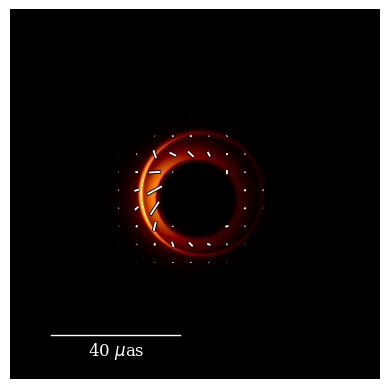

clipping values leq 0 in pol display


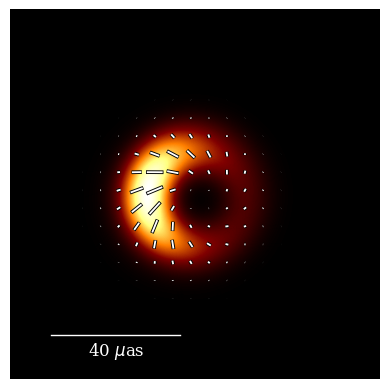

In [11]:
# display image
if display_image:
    im.rotate(rotation).display(
                 cbar_unit=['Tb'],has_cbar=False,label_type='scale',has_title=False,
                 plotp=polarization,pcut=.001,scale_ticks=True,nvec=20)
    im.blur_circ(10*eh.RADPERUAS,10*eh.RADPERUAS).rotate(rotation).display(
                 cbar_unit=['Tb'],has_cbar=False,label_type='scale',has_title=False,
                 plotp=polarization,pcut=.001,scale_ticks=True,nvec=20)

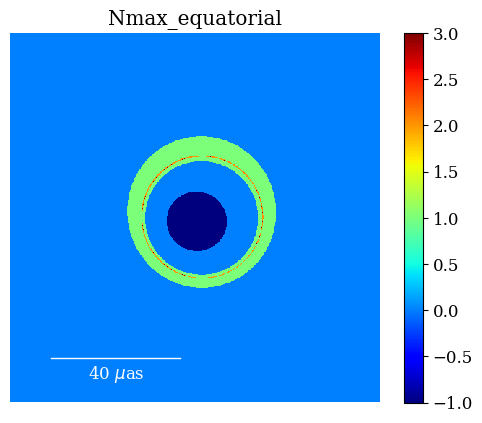

In [25]:
# make a image of the subring number and save
narr = np.flipud(outarr_n.reshape(npix,npix))   # number of equatorial crossings
narr[narr==-2]=-1 # mask out vortical geodesics
imn = eh.image.Image(narr, psize_rad, ra, dec)
imn.source = source
if save_image: imn.save_fits('./m87_model_%s_n.fits'%label)
if display_image: 
    imn.display(label_type='scale',cfun='jet',has_cbar=False,interp=None,show=False)
    plt.title('Nmax_equatorial');
    plt.colorbar(label='')
    

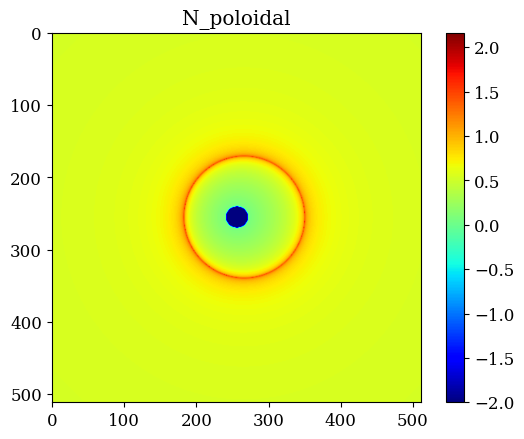

In [26]:
nparr = np.flipud(outarr_np.reshape(npix,npix)) # fractional number of poloidal orbits
imnp = eh.image.Image(nparr, psize_rad, ra, dec)
imnp.source = source
if save_image:  imnp.save_fits('./m87_model_%s_np.fits'%label)
if display_image: 
    imnp.display(label_type='jet',cfun='jet',has_cbar=False,show=False)
    plt.title('N_poloidal')
    plt.colorbar(label='')
    

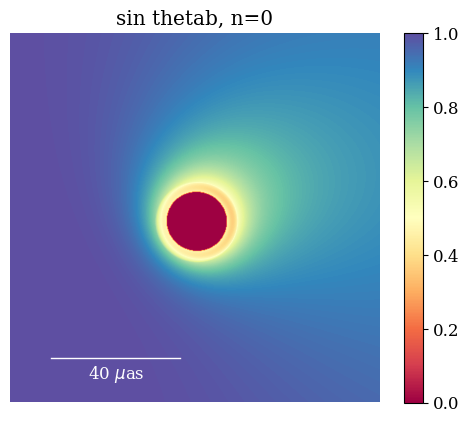

In [27]:
if polarization:
    # make a image of the n=0 sin^theta term and save
    stharr = np.flipud(outarr_sinthb[:,0].reshape(npix,npix))   # sin(theta)
    imsth = eh.image.Image(stharr, psize_rad, ra, dec)
    #imsth = eh.image.Image(stharr**2/np.max(stharr**2), psize_rad, ra, dec)
    imsth.source = source
    if save_image:  imsth.save_fits('./m87_model_%s_sinthb.fits'%label)
    if display_image: 
        imsth.rotate(rotation).display(label_type='scale',cfun='Spectral',has_cbar=False,show=False)
        plt.title('sin thetab, n=0')
        plt.colorbar(label='')

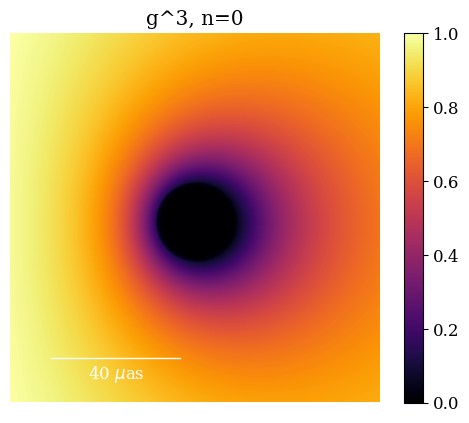

In [28]:
if polarization:
    # make a image of the n=0 doppler factor and save
    garr = np.flipud(outarr_g[:,0].reshape(npix,npix))   # number of equatorial crossings
    img = eh.image.Image(garr**3/np.max(garr**3), psize_rad, ra, dec)
    img.source = source
    if save_image:  img.save_fits('./m87_model_%s_g3.fits'%label)
    if display_image: 
        img.rotate(rotation).display(label_type='scale',cfun='inferno',has_cbar=False,show=False)
        plt.title('g^3, n=0')
        plt.colorbar(label='')